In [1]:
import pandas as pd
import pickle as pkl
import json
import numpy as np
from sklearn.metrics import root_mean_squared_error
import matplotlib.pyplot as plt

In [87]:
# load in test data
with open('../data/processed/df_tabular_test.pkl', 'rb') as f:
    df = pkl.load(f)

In [3]:
# load in the model - just use XGBOost for now
with open('../models/XGBoost.pkl', 'rb') as f:
    model = pkl.load(f)

In [4]:
with open('../data/processed/mean_std_per_client.json', 'r') as f:
    df_std_mean_usage = pd.read_json(f).T
    # create dictionary version for fast lookup
    dict_std_mean_usage = df_std_mean_usage.to_dict(orient='index')

In [ ]:
X_test = df.drop(columns=['hourly_usage_kwh'])
y_test = df['hourly_usage_kwh']

In [ ]:
def remove_first_week_and_up_to_first_6am_before_last_5am(g):
    """ takes a group and removes the first week of data (naive assumption that all data included for now!)
    and then data up to the first 6 am (first forecast step) """

    # first remove first week
    g_minus_1wk = g[168:]

    # get min datetime that is 6am
    datetimes = g_minus_1wk.index.get_level_values('datetime')
    # client_id = g.index.get_level_values('client_id').unique()
    min_6am = np.min(datetimes[datetimes.hour == 6])
    max_6am = np.max(datetimes[datetimes.hour == 6])

    # get index of min 6am and max 5am
    idx_min_6am = g_minus_1wk.index.droplevel('client_id').get_loc(min_6am)
    idx_max_6am = g_minus_1wk.index.droplevel('client_id').get_loc(max_6am)

    return g_minus_1wk.iloc[idx_min_6am:idx_max_6am]

# get version of data with first week removed as well as before first valid 6 am and after last valid 6am - to get 
# datetimes that predictions to be made for
X_test_data_removed = X_test.groupby(level='client_id').apply(lambda g: remove_first_week_and_up_to_first_6am_before_last_5am(g))

# remove duplicate multiindex client id level
X_test_data_removed.index = X_test_data_removed.index.droplevel(0)

print(len(X_test))
print(len(X_test_data_removed))

# get datetimes (and corresponding client id) at 6am, forming first forecast point for client at corresponding index
datetimes_forecast_start = X_test_data_removed.index[X_test_data_removed.index.get_level_values('datetime').hour == 6]

701300
681600


In [ ]:
# forecast horizon of 24 hours
HORIZON = 24
CONTEXT_WINDOW = 168

# need to get indexes corresponding to each column
col_idxs = {col: i for i, col in enumerate(X_test.columns)}
col_idxs

{'hour_sin': 0,
 'hour_cos': 1,
 'day_sin': 2,
 'day_cos': 3,
 'month_sin': 4,
 'month_cos': 5,
 'lag_1hr': 6,
 'lag_2hr': 7,
 'lag_6hr': 8,
 'lag_1dy': 9,
 'lag_1wk': 10,
 'rolling_mean_1dy': 11,
 'rolling_mean_1wk': 12,
 'rolling_max_1dy': 13,
 'rolling_max_1wk': 14,
 'rolling_min_1dy': 15,
 'rolling_min_1wk': 16,
 'rolling_std_1dy': 17,
 'rolling_std_1wk': 18,
 'mean_usage': 19}

In [ ]:
# convert x and y to array
X_test_array = X_test.to_numpy()
y_test_array = y_test.to_numpy()

# because pre-removed data, num context windows is just number of starting time points
num_context_windows = len(datetimes_forecast_start)

# create matrix for the predictions (context windows and hours of day)
# will get datetime corresponding to each context window later
y_preds_array = np.zeros((num_context_windows, HORIZON))

In [162]:
def update_the_feature_array(initial_features_indexes, hour_index):

    """ take the index of data to collect and recompute lag and rolling features, ready for 
    prediction """
    
    # get exisiting feature values at each initial forecast step (using single step
    # engineered features as baseline) 
    feature_array = X_test_array[initial_features_indexes + hour_index, :]

    # expand dims for indexes so can broadcast later when want range of indexes
    initial_features_indexes = np.expand_dims(initial_features_indexes, axis=-1)

    # use np.arange to extract contigous indexes (i.e., window; first axis) for each context window (zeroth axis)
    data_from_target = y_test_array[initial_features_indexes + hour_index - 168 + np.arange(168 - hour_index)]
    # then get data from preds
    data_from_preds = y_preds_array[:, :hour_index]
    # then combine
    data_to_process = np.concat((data_from_target, data_from_preds), axis=-1)

    # recompute lag features
    feature_array[:, col_idxs['lag_1hr']] = data_to_process[:, -1]
    feature_array[:, col_idxs['lag_2hr']] = data_to_process[:, -2]
    feature_array[:, col_idxs['lag_6hr']] = data_to_process[:, -6]
    feature_array[:, col_idxs['lag_1dy']] = data_to_process[:, -24]
    feature_array[:, col_idxs['lag_1wk']] = data_to_process[:, -168]

    # and the rolling features
    feature_array[:, col_idxs['rolling_mean_1dy']] = np.mean(data_to_process[:, -24:], axis=-1)
    feature_array[:, col_idxs['rolling_mean_1wk']] = np.mean(data_to_process[:, -168:], axis=-1)

    feature_array[:, col_idxs['rolling_max_1dy']] = np.max(data_to_process[:, -24:], axis=-1)
    feature_array[:, col_idxs['rolling_max_1wk']] = np.max(data_to_process[:, -168:], axis=-1)

    feature_array[:, col_idxs['rolling_min_1dy']] = np.min(data_to_process[:, -24:], axis=-1)
    feature_array[:, col_idxs['rolling_min_1wk']] = np.min(data_to_process[:, -168:], axis=-1)

    return feature_array

In [ ]:
############
# get indexes of first forecast datetimes within the testing data array
# initial_features_indexes = X_test.index.droplevel('client_id').get_indexer(starting_dates_for_test)
initial_features_indexes = X_test.index.get_indexer(datetimes_forecast_start)


# loop over each hour to forecast (index zero starts at 6am)
for hour_index in range(HORIZON):

    if hour_index == 0:
        # if hour is zero, then just take the feature values from test data (already in correct order)
        feature_array = X_test.iloc[initial_features_indexes].values
    else:
        # otherwise concat exisiting observed data with predictions (recursive step)
        feature_array = update_the_feature_array(initial_features_indexes=initial_features_indexes, 
                                                 hour_index=hour_index)
    
    # update the predictions matrix
    y_preds_array[:, hour_index] = model.predict(feature_array)

In [166]:
def unscale_per_client(group, dict_with_mean_and_std):
    """ use mean and std usage for each client to unscale data, ready for 
    evaluation """

    client_id = int(np.unique(group.index.get_level_values('client_id'))[0])

    return ((group * dict_with_mean_and_std[client_id]['std']) + dict_with_mean_and_std[client_id]['mean'])

In [170]:
# create dataframe for predictions
df_preds = pd.DataFrame(data=y_preds_array.flatten(), index=X_test_data_removed.index, columns=['y_pred'])

# filter into testing data to get actual values
df_preds['y_true'] = y_test[y_test.index.isin(X_test_data_removed.index)]

# unscale the predictions
df_preds_unscaled = df_preds.groupby(level='client_id').transform(lambda g: unscale_per_client(g, dict_std_mean_usage))

In [178]:
# for each client compute the rmse
rmse_per_client = df_preds_unscaled.groupby(level='client_id').apply(lambda g: root_mean_squared_error(g['y_true'], g['y_pred']))

# normalise rmse by mean usage to make comparable across clients
nrmse_per_client = rmse_per_client/df_std_mean_usage['mean']

# create dict of summary stats
summary_dict = {
                'mean': nrmse_per_client.mean(),
                'std': nrmse_per_client.std(),
                'max': nrmse_per_client.max(),
                'min': nrmse_per_client.min(),
                'top_5_performing_clients': list(nrmse_per_client.sort_values().iloc[:5].index),
                'bottom_5_performing_clients': list(nrmse_per_client.sort_values(ascending=False).iloc[:5].index),
                }

summary_dict

{'mean': np.float64(0.13345109964931215),
 'std': np.float64(0.14694956673354068),
 'max': np.float64(1.2383248625553753),
 'min': np.float64(0.03216499859053596),
 'top_5_performing_clients': [147, 145, 281, 329, 250],
 'bottom_5_performing_clients': [132, 366, 36, 156, 151]}

Now get predictions from single timestep model to compare

In [ ]:
# get predictions from single timestep prediction
y_preds_single_step = model.predict(X_test[X_test.index.isin(X_test_data_removed.index)])

# create df from predictions
df_single_preds = pd.DataFrame(data={'y_pred': y_preds_single_step, 'y_true': y_test[y_test.index.isin(X_test_data_removed.index)]}, index=df_preds.index)

# scale the predictions
df_single_preds_unscaled = df_single_preds.groupby(level='client_id').transform(lambda g: unscale_per_client(g, dict_std_mean_usage))

In [176]:
# for each client compute the rmse
rmse_per_client_single = df_single_preds_unscaled.groupby(level='client_id').apply(lambda g: root_mean_squared_error(g['y_true'], g['y_pred']))

# normalise rmse by mean usage to make comparable across clients
nrmse_per_client_single = rmse_per_client_single/df_std_mean_usage['mean']

# create dict of summary stats
summary_dict_single = {
                'mean': nrmse_per_client_single.mean(),
                'std': nrmse_per_client_single.std(),
                'max': nrmse_per_client_single.max(),
                'min': nrmse_per_client_single.min(),
                'top_5_performing_clients': list(nrmse_per_client_single.sort_values().iloc[:5].index),
                'bottom_5_performing_clients': list(nrmse_per_client_single.sort_values(ascending=False).iloc[:5].index),
                }

In [177]:
summary_dict_single

{'mean': np.float64(0.07549143616747733),
 'std': np.float64(0.048756715560783356),
 'max': np.float64(0.3905442469847266),
 'min': np.float64(0.01664533791449831),
 'top_5_performing_clients': [147, 145, 150, 210, 250],
 'bottom_5_performing_clients': [132, 366, 36, 354, 23]}

Plotting


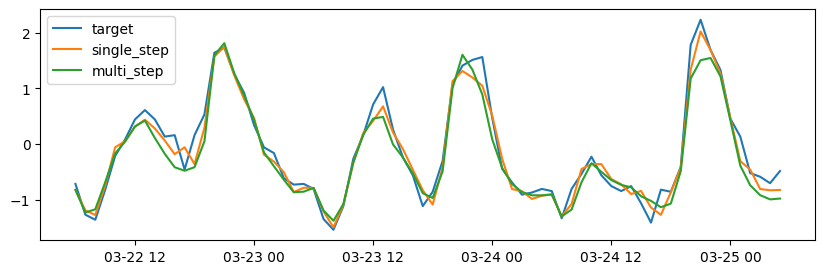

In [180]:
datetimes_to_plot = X_test_data_removed.index.get_level_values('datetime')[:72]


plt.figure(figsize=(10, 3))
plt.plot(datetimes_to_plot, df_single_preds['y_true'].iloc[:72], label='target')
plt.plot(datetimes_to_plot, df_single_preds['y_pred'].iloc[:72], label='single_step')
plt.plot(datetimes_to_plot, df_preds['y_pred'].iloc[:72], label='multi_step')
plt.legend()
plt.show()